SHAP Installation

In [ ]:
!pip install shap xgboost

GPU Enabling

In [ ]:
!nvidia-smi
!pip install --upgrade xgboost
print("To use GPU in XGBoost, set tree_method='gpu_hist', predictor='gpu_predictor'.")

/bin/bash: line 1: nvidia-smi: command not found
To use GPU in XGBoost, set tree_method='gpu_hist', predictor='gpu_predictor'.


Import Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()
list(uploaded.keys())

Saving Utica_8-6_activity_training_kWH.csv to Utica_8-6_activity_training_kWH (1).csv


['Utica_8-6_activity_training_kWH (1).csv']

Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt
import joblib
import time
import os
shap.initjs()

Load Dataset

In [ ]:
df = pd.read_csv('Utica_8-6_activity_training_kWH.csv')
df['time'] = pd.to_datetime(df['time'])
df.head()

,time,temperature,humidity,precipitation (inch),rain (inch),snowfall (inch),snow_depth (ft),wind_speed_10m (km/h),cloud_cover,kWh,school_factor,kWh_adjusted,hour,day_of_week
0,2025-01-13 00:00:00,32.5,32,0.0,0.0,0.0,0.427,1.4,0,34.031897,0.75,25.523923,0,0
1,2025-01-13 01:00:00,36.5,34,0.0,0.0,0.0,0.427,1.3,0,24.127403,0.75,18.095552,1,0
2,2025-01-13 02:00:00,38.1,40,0.0,0.0,0.0,0.427,2.6,0,25.035096,0.75,18.776322,2,0
3,2025-01-13 03:00:00,38.3,42,0.0,0.0,0.0,0.427,2.2,0,22.611535,0.75,16.958652,3,0
4,2025-01-13 04:00:00,38.0,40,0.0,0.0,0.0,0.427,1.1,0,25.376619,0.75,19.032464,4,0


Feature & Target Selection

In [ ]:
features = ['temperature', 'humidity', 'cloud_cover', 'hour', 'day_of_week', 'school_factor']
target = 'kWh_adjusted'
X = df[features].values
y = df[target].values
X.shape, y.shape

((2904, 6), (2904,))

Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((2323, 6), (581, 6))

Define Models

In [ ]:
models = {'Linear Regression': LinearRegression(n_jobs=-1), 'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1), 'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42), 'XGBoost': XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, n_jobs=-1, objective='reg:squarederror')}
list(models.keys())

['Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']

SHAP Explainability


Training Linear Regression...


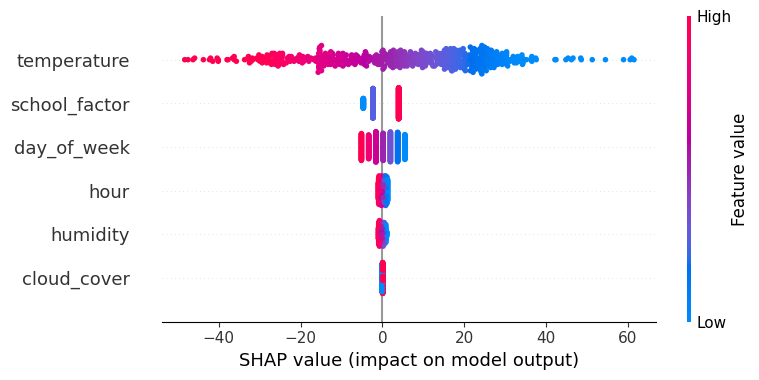

<Figure size 640x480 with 0 Axes>

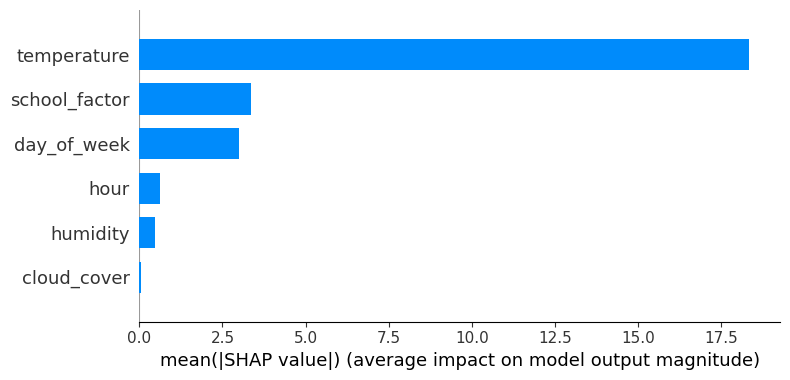

<Figure size 640x480 with 0 Axes>

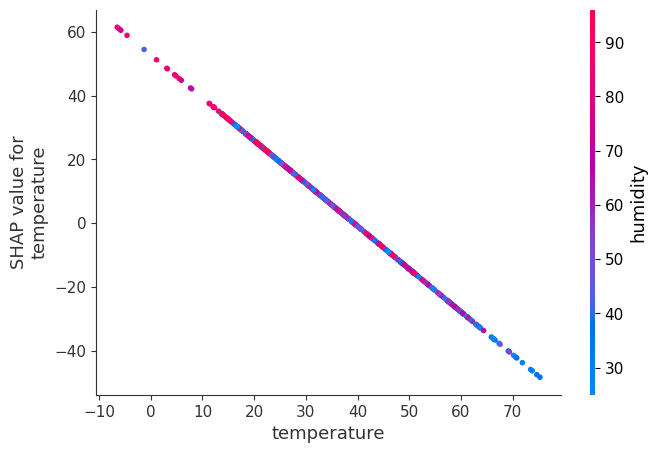

<Figure size 640x480 with 0 Axes>


Training Random Forest...


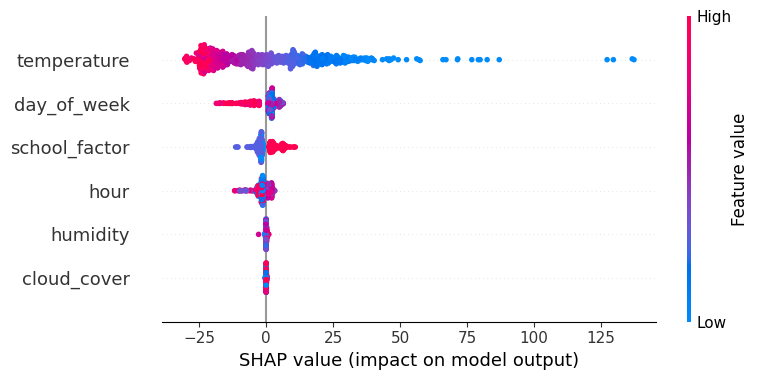

<Figure size 640x480 with 0 Axes>

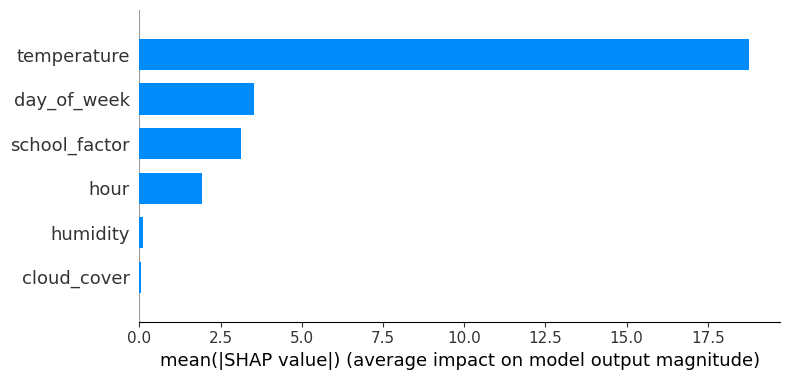

<Figure size 640x480 with 0 Axes>

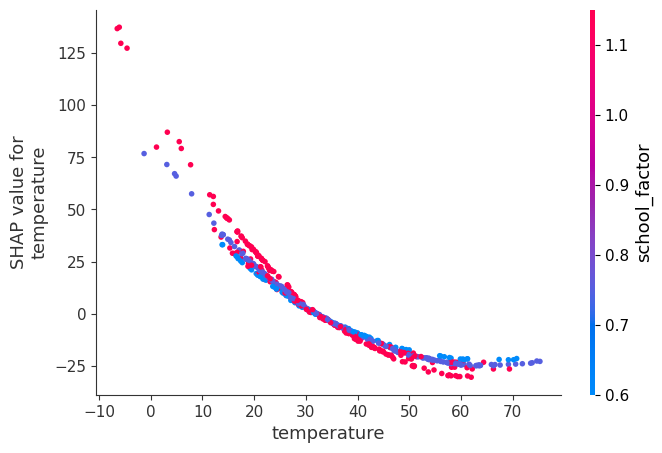

<Figure size 640x480 with 0 Axes>


Training Gradient Boosting...


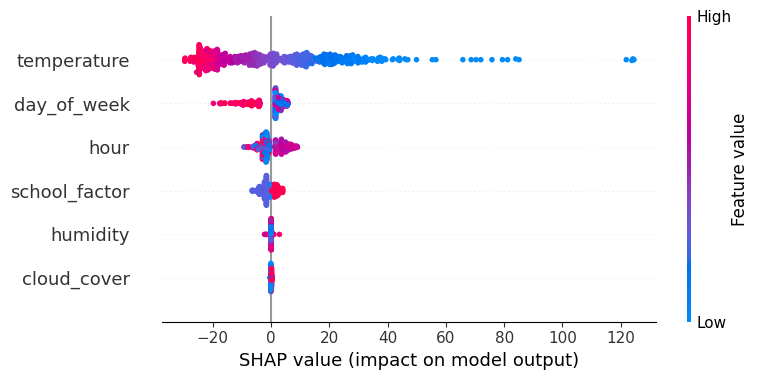

<Figure size 640x480 with 0 Axes>

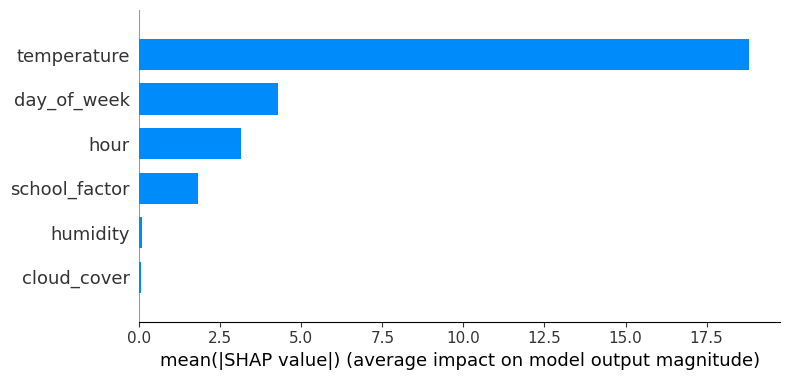

<Figure size 640x480 with 0 Axes>

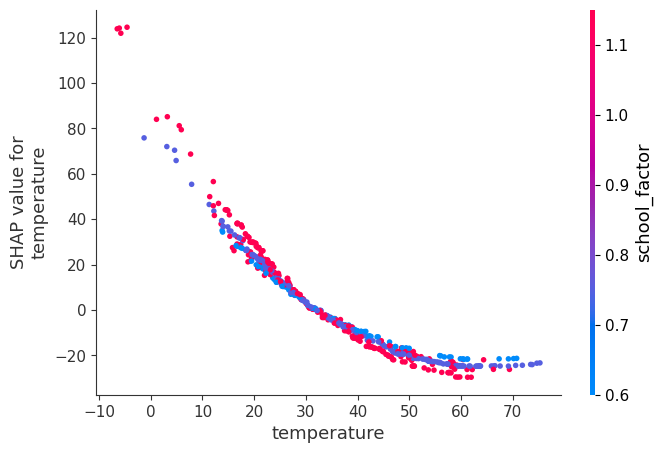

<Figure size 640x480 with 0 Axes>


Training XGBoost...


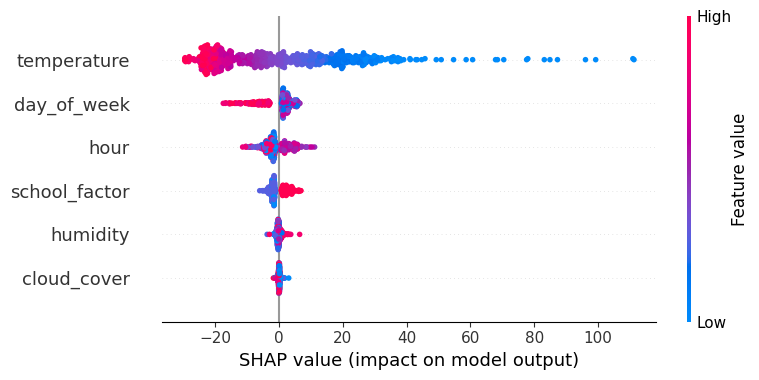

<Figure size 640x480 with 0 Axes>

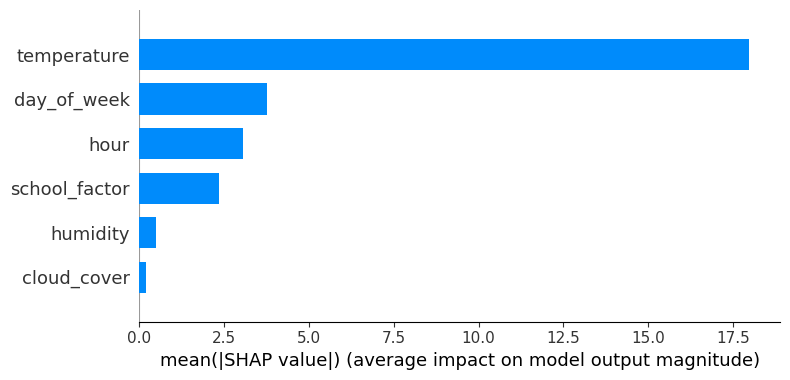

<Figure size 640x480 with 0 Axes>

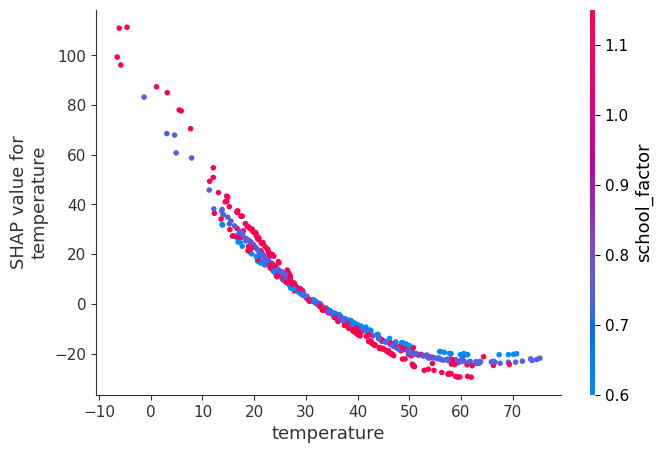

<Figure size 640x480 with 0 Axes>

,Model,MSE,MAE,R²,Train Time (sec),Latency (sec/pred)
0,Linear Regression,168.408112,8.521203,0.767421,0.007933,0.000001
1,Random Forest,4.405200,0.966931,0.993916,3.304655,0.000254
2,Gradient Boosting,4.733725,1.400743,0.993463,0.697675,0.000006
3,XGBoost,9.699808,1.324971,0.986604,0.379170,0.000012


In [ ]:
results = []
train_times = {}
inference_times = {}
shap_importances = {}
os.makedirs('shap_plots', exist_ok=True)

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    train_times[name] = end - start

    start = time.time()
    y_pred = model.predict(X_test)
    end = time.time()
    inference_times[name] = (end - start) / len(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append([name, mse, mae, r2, train_times[name], inference_times[name]])

    if name == 'Linear Regression':
        explainer = shap.LinearExplainer(model, X_train)
        shap_values = explainer.shap_values(X_test)
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)

    shap_importances[name] = np.mean(np.abs(shap_values), axis=0)
    plt.figure(figsize=(8,6))
    plt.close()
    shap.summary_plot(shap_values, X_test, feature_names=features)
    plt.tight_layout()
    plt.show()
    plt.savefig(f'shap_plots/{name}_summary.png', dpi=300, bbox_inches='tight')
    plt.close()
    plt.figure(figsize=(8,6))
    plt.close()
    shap.summary_plot(shap_values, X_test, feature_names=features, plot_type='bar')
    plt.tight_layout()
    plt.show()
    plt.savefig(f'shap_plots/{name}_bar.png', dpi=300, bbox_inches='tight')
    plt.close()
    plt.figure(figsize=(8,6))
    plt.close()
    shap.dependence_plot('temperature', shap_values, X_test, feature_names=features)
    plt.tight_layout()
    plt.show()
    plt.savefig(f'shap_plots/{name}_temp_dependence.png', dpi=300, bbox_inches='tight')
    plt.close()

results_df = pd.DataFrame(results, columns=['Model', 'MSE', 'MAE', 'R²', 'Train Time (sec)', 'Latency (sec/pred)'])
results_df

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Timing & Latency Comparison Table

In [ ]:
timing_df = pd.DataFrame({'Model': list(train_times.keys()), 'Training Time (sec)': list(train_times.values()), 'Inference Latency (sec/pred)': list(inference_times.values())})
timing_df

,Model,Training Time (sec),Inference Latency (sec/pred)
0,Linear Regression,0.007933,0.000001
1,Random Forest,3.304655,0.000254
2,Gradient Boosting,0.697675,0.000006
3,XGBoost,0.379170,0.000012


SHAP Feature Importance Comparison Table

In [ ]:
shap_table = pd.DataFrame(shap_importances, index=features)
shap_table

,Linear Regression,Random Forest,Gradient Boosting,XGBoost
temperature,18.355580,18.785670,18.825659,17.988865
humidity,0.475001,0.108033,0.086167,0.502221
cloud_cover,0.048449,0.054983,0.064558,0.202794
hour,0.619841,1.944241,3.147601,3.068638
day_of_week,2.990244,3.535081,4.269181,3.750858
school_factor,3.372172,3.117340,1.821797,2.358557


Stacking Ensemble

In [ ]:
base_learners = [
    ('linear', LinearRegression(n_jobs=-1)),
    ('rf', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    ('gbr', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, n_jobs=-1, objective='reg:squarederror'))
]
meta_model = LinearRegression(n_jobs=-1)
stack_model = StackingRegressor(estimators=base_learners, final_estimator=meta_model, passthrough=True, n_jobs=-1)
stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)
stack_mse = mean_squared_error(y_test, stack_pred)
stack_mae = mean_absolute_error(y_test, stack_pred)
stack_r2 = r2_score(y_test, stack_pred)
stack_mse, stack_mae, stack_r2

(4.855380587462998, 1.1682225039312064, 0.9932945199138223)

Residual Plot

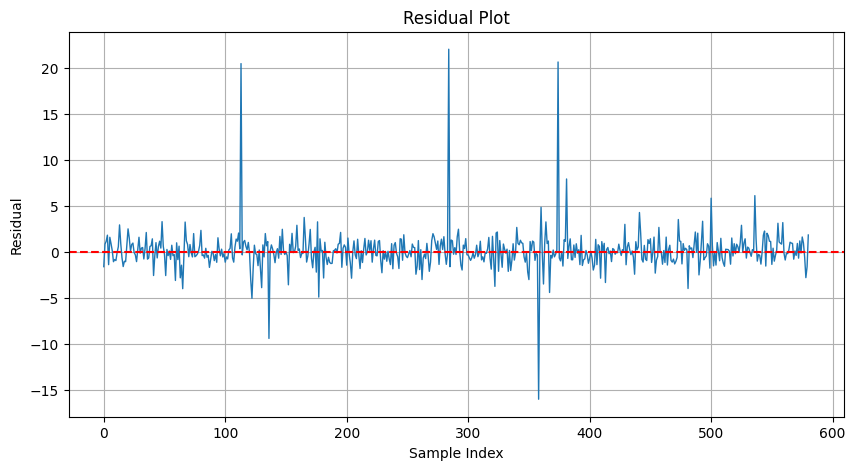

In [ ]:
model_to_analyze = stack_model
y_pred = model_to_analyze.predict(X_test)
residuals = y_test - y_pred
plt.figure(figsize=(10,5))
plt.plot(residuals, linewidth=1)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Sample Index')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

Error Histogram

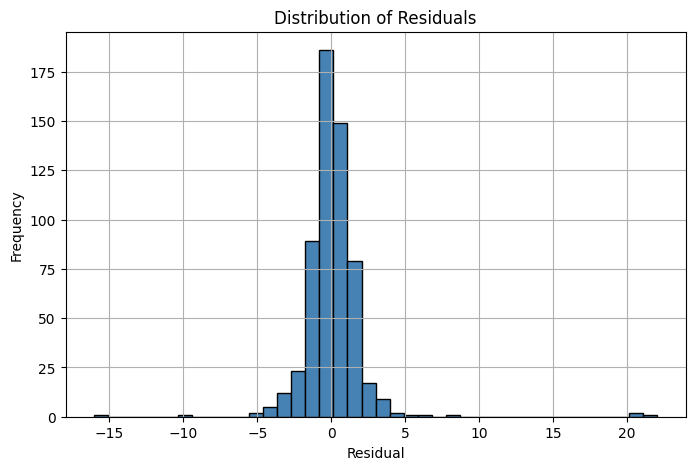

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Actual vs Predicted

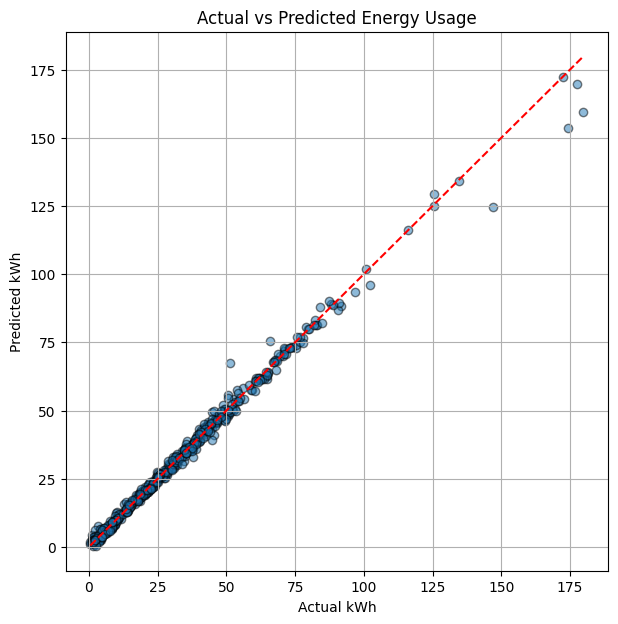

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel('Actual kWh')
plt.ylabel('Predicted kWh')
plt.title('Actual vs Predicted Energy Usage')
plt.grid(True)
plt.show()

Error vs Hour_of_Day

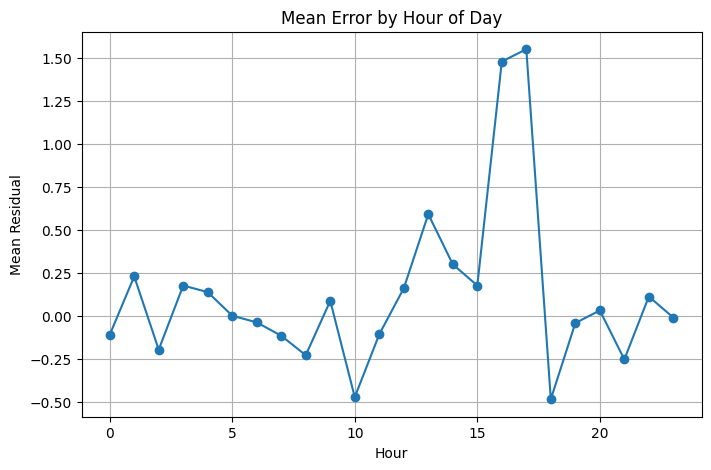

In [ ]:
test_hours = X_test[:, features.index('hour')]
df_err = pd.DataFrame({'hour': test_hours, 'error': residuals})
hourly_error = df_err.groupby('hour')['error'].mean()
plt.figure(figsize=(8,5))
plt.plot(hourly_error.index, hourly_error.values, marker='o')
plt.title('Mean Error by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Mean Residual')
plt.grid(True)
plt.show()

Error vs Temperature

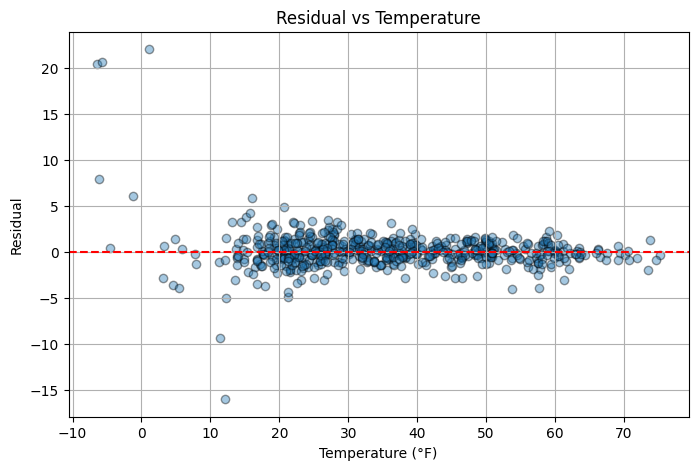

In [ ]:
test_temp = X_test[:, features.index('temperature')]
plt.figure(figsize=(8,5))
plt.scatter(test_temp, residuals, alpha=0.4, edgecolor='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Temperature (°F)')
plt.ylabel('Residual')
plt.title('Residual vs Temperature')
plt.grid(True)
plt.show()

Error Stats Summary

In [ ]:
error_stats = pd.DataFrame({
    'Mean Error': [np.mean(residuals)],
    'Median Error': [np.median(residuals)],
    'Std Dev': [np.std(residuals)],
    'MAE': [mean_absolute_error(y_test, y_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred))]
})
error_stats

,Mean Error,Median Error,Std Dev,MAE,RMSE
0,0.111,0.026581,2.200695,1.168223,2.203493


Local Interpretability

In [ ]:
# Testing with Stack Ensemble
# Select one test example to explain
sample_idx = 0  # change this index to inspect other hours
x_explain = X_test[sample_idx:sample_idx+1]

# Use a small background set for KernelExplainer
background_size = min(100, X_train.shape[0])
background = X_train[np.random.choice(X_train.shape[0], size=background_size, replace=False)]

kernel_explainer = shap.KernelExplainer(stack_model.predict, background)
shap_values_local = kernel_explainer.shap_values(x_explain)

shap_values_local

  0%|          | 0/1 [00:00<?, ?it/s]

array([[26.49100182,  0.46566194,  0.26169611, -1.82440567, -7.99261138,
        -0.24507542]])

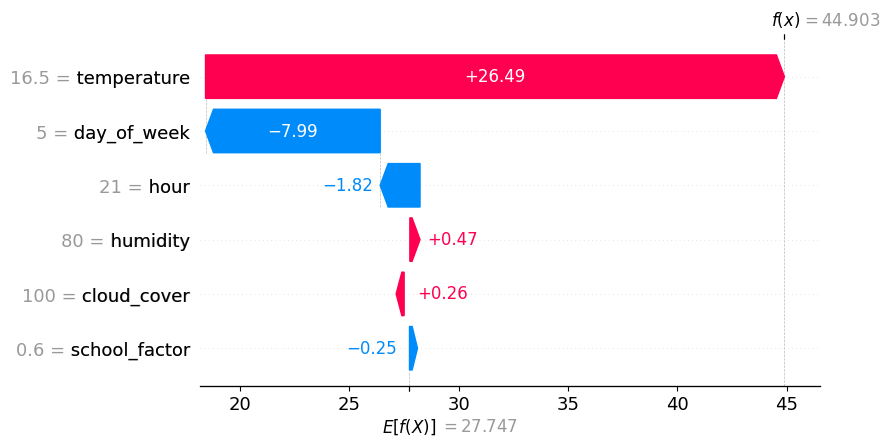

In [ ]:
# Local Waterfall/Force Plot
try:
    # Newer SHAP API: waterfall plot using Explanation object
    exp = shap.Explanation(
        values=shap_values_local[0],
        base_values=kernel_explainer.expected_value,
        data=x_explain[0],
        feature_names=features
    )
    shap.plots.waterfall(exp)
except Exception as e:
    print('Waterfall plot not available, falling back to force_plot.')
    shap.force_plot(kernel_explainer.expected_value, shap_values_local[0], x_explain, feature_names=features)

XGRegressor Error Handling

In [ ]:
from xgboost import XGBRegressor
from skl2onnx import update_registered_converter
from skl2onnx.common.shape_calculator import calculate_linear_regressor_output_shapes
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost

# Register converter for XGBRegressor so skl2onnx knows how to handle it
update_registered_converter(
    XGBRegressor,
    "XGBoostXGBRegressor",
    calculate_linear_regressor_output_shapes,
    convert_xgboost,
)

Save and Export Model(s) to compressed folder (contains .pkl and .onnx)

In [ ]:
!pip install skl2onnx onnxmltools onnxruntime
# SAFE MODEL EXPORTER — NO ONNX OPTIMIZATION=
# NOTE: ONNX No longer used for C++, so only .pkl files are absolutely necessary

import os, shutil, zipfile
from google.colab import drive
import joblib
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Mount Google Drive
drive.mount('/content/drive')

EXPORT_DIR = "/content/drive/MyDrive/MLModelExports"
if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)
os.makedirs(EXPORT_DIR, exist_ok=True)

print("Google Drive export directory:", EXPORT_DIR)

# Define simple save helpers (no optimization)

initial_type = [('input', FloatTensorType([None, X_train.shape[1]]))]

def save_model_pkl(model, name):
    out = f"{EXPORT_DIR}/{name}.pkl"
    joblib.dump(model, out)
    print("Saved PKL:", out)

#def save_model_onnx(model, name):
    #out = f"{EXPORT_DIR}/{name}.onnx"
    #try:
        #onnx_model = convert_sklearn(model, initial_types=initial_type)
        #with open(out, "wb") as f:
            #f.write(onnx_model.SerializeToString())
        #print("Saved ONNX:", out)
    #except Exception as e:
        #print(f"[ERROR] Could not convert {name} to ONNX:", e)

# Export all models (PKL + ONNX)

save_model_pkl(models['Linear Regression'], "linear_model")
#save_model_onnx(models['Linear Regression'], "linear_model")

save_model_pkl(models['Random Forest'], "rf_model")
#save_model_onnx(models['Random Forest'], "rf_model")

save_model_pkl(models['Gradient Boosting'], "gbr_model")
#save_model_onnx(models['Gradient Boosting'], "gbr_model")

save_model_pkl(models['XGBoost'], "xgb_model")
#save_model_onnx(models['XGBoost'], "xgb_model")

save_model_pkl(stack_model, "stack_model")
#save_model_onnx(stack_model, "stack_model")

print("\nAll PKL files exported (no optimization).\n")

# ZIP all exported models (ZIP64 enabled)

ZIP_PATH = f"{EXPORT_DIR}/energy_ml_models.zip"
with zipfile.ZipFile(
    ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    allowZip64=True
) as zf:
    for file in os.listdir(EXPORT_DIR):
        if file.endswith(".onnx") or file.endswith(".pkl"):
            zf.write(os.path.join(EXPORT_DIR, file), file)

print("ZIP package created:", ZIP_PATH)
print("SAFE EXPORT COMPLETE")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive export directory: /content/drive/MyDrive/MLModelExports
Saved PKL: /content/drive/MyDrive/MLModelExports/linear_model.pkl
Saved PKL: /content/drive/MyDrive/MLModelExports/rf_model.pkl
Saved PKL: /content/drive/MyDrive/MLModelExports/gbr_model.pkl
Saved PKL: /content/drive/MyDrive/MLModelExports/xgb_model.pkl
Saved PKL: /content/drive/MyDrive/MLModelExports/stack_model.pkl

All PKL files exported (no optimization).

ZIP package created: /content/drive/MyDrive/MLModelExports/energy_ml_models.zip
SAFE EXPORT COMPLETE
